# Topic 2: Recommendation System
### Demo: Gemsim, Cosin Similarity

In [1]:
# cài đặt các thư viện cần thiết này trên máy (nếu chưa cài)
# !pip install gensim
# !pip install pyvi
# !pip install beautifulsoup4

In [2]:
from pyvi import ViTokenizer

s = "Tôi yêu thành phố Hồ Chí Minh"
print(ViTokenizer.tokenize(s))

Tôi yêu thành_phố Hồ_Chí_Minh


In [3]:
# Note: Có thể tùy chọn các thư việc xử lý tiếng Việt

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
# from underthesea import word_tokenize, pos_tag, sent_tokenize
from pyvi.ViTokenizer import tokenize
import warnings
from gensim import corpora, models, similarities
import re
from bs4 import BeautifulSoup
warnings.filterwarnings('ignore')

In [5]:
# from google.colab import drive
# drive.mount("/content/gdrive", force_remount=True)

In [6]:
# %cd '/content/gdrive/MyDrive/LDS0/Khoa_311/Project_2_ContentBased_Segmentation/demo_HV'

In [7]:
STOP_WORD_FILE = 'files/vietnamese-stopwords.txt'

In [8]:
with open(STOP_WORD_FILE, 'r', encoding='utf-8') as file:
    stop_words = file.read()

stop_words = stop_words.split('\n')

In [9]:
# Đọc file excel abc.csv
df = pd.read_csv('house_samples.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   11 non-null     int64  
 1   tieu_de              11 non-null     object 
 2   gia_ban              11 non-null     object 
 3   don_gia              11 non-null     object 
 4   dien_tich            11 non-null     object 
 5   dia_chi              11 non-null     object 
 6   mo_ta                11 non-null     object 
 7   dien_thoai           6 non-null      object 
 8   loai_hinh            11 non-null     object 
 9   dien_tich_dat        11 non-null     object 
 10  dien_tich_su_dung    5 non-null      object 
 11  gia_m2               11 non-null     object 
 12  giay_to_phap_ly      11 non-null     object 
 13  so_phong_ngu         11 non-null     object 
 14  so_phong_ve_sinh     10 non-null     object 
 15  tong_so_tang         10 non-null     float

In [11]:
df.head(2)

,id,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,...,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia,Quan
0,1,"Bán nhà Hoàng Hoa Thám, p.7 Bình Thạnh, 19m2, ...","3,98 tỷ","209,47 triệu/m²",19 m²,"Đường Hoàng Hoa Thám, Phường 7, Quận Bình Thạn...","#HHHHT012\nBán nhà Hoàng Hoa Thám, p.7 Bình Th...",090308 ***,"Nhà ngõ, hẻm",19 m²,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[138.46, 134.66, 134.66, 155.56, 142.38, 142.3...",Bình Thạnh
1,2,SIÊU PHẨM 6 TẦNG LẦU ĐÓN TẾT NGAY TRUNG TÂM 4 ...,"7,98 tỷ",228 triệu/m²,35 m²,"Đường Vạn Kiếp, Phường 3, Quận Bình Thạnh, Tp ...",SIÊU PHẨM 6 TẦNG LẦU ĐÓN TẾT NGAY TRUNG TÂM 4 ...,091507 ***,"Nhà ngõ, hẻm",35 m²,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[116.67, 116.67, 133.2, 126.92, 166.27, 166.27...",Bình Thạnh


In [12]:
# Làm sạch dữ liệu HTML và icon
def clean_html_icon(text):
    if pd.isna(text):
        return ""

    # 1. Loại bỏ các thẻ HTML
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    # 2. Loại bỏ Emojis và các ký tự biểu tượng đặc biệt
    # Cách này sử dụng Regex để giữ lại các ký tự chữ cái, số, dấu câu cơ bản và khoảng trắng
    # Loại bỏ các ký tự có dải Unicode đặc biệt (thường là icon/emoji)
    text = re.sub(r'[^\x00-\x7F\u00C0-\u1EF9]+', ' ', text)

    # 3. Làm sạch khoảng trắng và xuống dòng
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()

df["mo_ta_clean"] = df["mo_ta"].apply(clean_html_icon)

In [13]:
df[["mo_ta_clean"]].head()

,mo_ta_clean
0,"#hhhht012 bán nhà hoàng hoa thám, p.7 bình thạ..."
1,siêu phẩm 6 tầng lầu đón tết ngay trung tâm 4 ...
2,"diện tích : 4mx12m - cn: 46,6m kết cấu 1 trệt ..."
3,nhà đẹp đón tết - xô viết nghệ tĩnh f21 giáp q...
4,3 tầng- nhà mt đường số 1 p4 gv- hxt- 4 x 17m ...


In [14]:
# Tạo nội dung tổng hợp
# Lựa chọn các thông tin cần thiết để đưa vào phần content (giúp đề xuất nội dung)
# Có thể 1 cột hoặc nhiều cột thông tin
# ví dụ ở đây là chọn 1 cột, và chỉ lấy 200 từ đầu tiên trong phần mô tả (dễ quan sát khi làm demo)
df['Content'] = df['mo_ta_clean'].apply(lambda x: ' '.join(x.split()[:200]))

In [15]:
df[['Content']].head()

,Content
0,"#hhhht012 bán nhà hoàng hoa thám, p.7 bình thạ..."
1,siêu phẩm 6 tầng lầu đón tết ngay trung tâm 4 ...
2,"diện tích : 4mx12m - cn: 46,6m kết cấu 1 trệt ..."
3,nhà đẹp đón tết - xô viết nghệ tĩnh f21 giáp q...
4,3 tầng- nhà mt đường số 1 p4 gv- hxt- 4 x 17m ...


In [16]:
# word_tokenize
df["Content_wt"]=df["Content"].apply(lambda x: tokenize(x))

In [17]:
df[["Content", "Content_wt"]].head(2)

,Content,Content_wt
0,"#hhhht012 bán nhà hoàng hoa thám, p.7 bình thạ...","# hhhht012 bán nhà hoàng hoa thám , p . 7 bình..."
1,siêu phẩm 6 tầng lầu đón tết ngay trung tâm 4 ...,siêu phẩm 6 tầng lầu đón tết ngay trung_tâm 4 ...


# Cosine_similarity
- link https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
- link https://en.wikipedia.org/wiki/Cosine_similarity
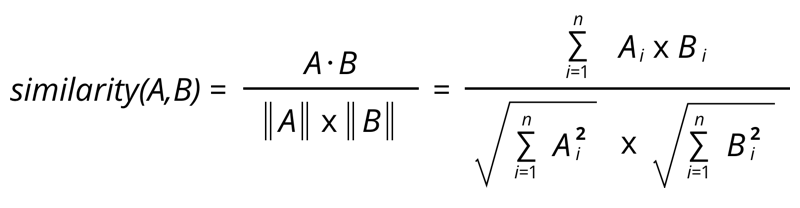

In [18]:
from numpy import dot
from numpy.linalg import norm
A = [1,2]
B = [2,2]
cos_sim = dot(A,B) / (norm(A)*norm(B))
print(cos_sim)

0.9486832980505138


In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Vector hóa nội dung
vectorizer = TfidfVectorizer(analyzer='word', stop_words=stop_words)
tfidf_matrix = vectorizer.fit_transform(df['Content_wt'])

# Tính toán độ tương đồng
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix) # ~ 7000 x 7000

In [20]:
df_show = pd.DataFrame(cosine_sim)
df_show

,0,1,2,3,4,5,6,7,8,9,10
0,1.000000,0.181111,0.047150,0.074798,0.058635,0.158700,0.175087,0.111417,0.192844,0.201623,0.190445
1,0.181111,1.000000,0.088503,0.141522,0.074983,0.070756,0.101406,0.131770,0.067232,0.175195,0.101127
2,0.047150,0.088503,1.000000,0.000000,0.042028,0.113516,0.036737,0.139558,0.000000,0.106012,0.000000
3,0.074798,0.141522,0.000000,1.000000,0.000000,0.019124,0.000000,0.039773,0.038788,0.038927,0.107596
4,0.058635,0.074983,0.042028,0.000000,1.000000,0.061913,0.113641,0.054804,0.028733,0.068848,0.044595
5,0.158700,0.070756,0.113516,0.019124,0.061913,1.000000,0.149460,0.250222,0.088339,0.208296,0.045250
6,0.175087,0.101406,0.036737,0.000000,0.113641,0.149460,1.000000,0.186436,0.167272,0.088126,0.027876
7,0.111417,0.131770,0.139558,0.039773,0.054804,0.250222,0.186436,1.000000,0.060379,0.137103,0.073978
8,0.192844,0.067232,0.000000,0.038788,0.028733,0.088339,0.167272,0.060379,1.000000,0.084636,0.120109
9,0.201623,0.175195,0.106012,0.038927,0.068848,0.208296,0.088126,0.137103,0.084636,1.000000,0.128747


In [21]:
# Hàm đề xuất nhà
# # với mỗi nhà, lấy nums nhà tương quan nhất
def get_recommendations(id, cosine_sim=cosine_sim, nums=5):
    # 1. Lấy index của căn nhà dựa trên id
    idx = df.index[df['id'] == id][0]

    # 2. Tính toán điểm tương đương và sắp xếp
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 3. Lấy nums + 1 kết quả
    sim_scores = sim_scores[1:nums+1]

    # Tách riêng index và điểm số
    house_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    # 4. Trạo DataFrame kết quả
    result_df = df.iloc[house_indices].copy()

    # 5. Thêm cột độ tương đồng (chuyển sang %)
    result_df['similarity_score'] = [round(s * 100, 2) for s in scores]

    return result_df

In [22]:
pd.set_option('display.max_colwidth', None)
# id=1
df[df['id'] == 1]['mo_ta_clean']

0    #hhhht012 bán nhà hoàng hoa thám, p.7 bình thạnh, 19m2, 3 tầng, hẻm 2m, 3.x tỷ. 19m2 - 3 tầng đầy đủ nội thất nhỉnh 3 tỷ mô tả diện tích, kết cấu: 19m2 2pn, 3wc 1 trệt 2 lầu vị trí: hẻm ba gác thông muôn nơi, 15m ra hẻm xe hơi, cách mặt tiền 50m. vị trí giáp phú nhuận, bình thạnh, thuận tiện ra sân bay tân sơn nhất. gần chợ, siêu thị, trường học các cấp. khu vực dân trí cao. liền kề nguyễn văn đậu, phan đăng lưu pháp lý: chuẩn, sổ hồng công chứng 1p30s.,,,, giá: 3.98 tỷ điểm cộng: nhà mới xây, full nội thất chỉ dọn vào ở. liên hệ: hiếu huỳnh - nhà đất, số dđ/zalo: *** #hhnd85
Name: mo_ta_clean, dtype: object

In [23]:
# Gọi function
recommendations = get_recommendations(1)
print("Nhà tương tự:")
recommendations[["id", "mo_ta_clean", "similarity_score"]].head()

Nhà tương tự:


,id,mo_ta_clean,similarity_score
9,10,"hoàng hoa thám, phường 5, phú nhuận khu vip, dân trí cao, an ninh, di chuyển cực nhanh ra trung tâm & sân bay. - dt 34m (3.7 x 9m) + sân hông ~8m, công nhận đủ - trệt + 3 lầu + sân thượng | 5pn 4wc | có kho - nhà rất thoáng, phòng nào cũng có cửa sổ - tặng full nội thất, vào ở ngay - hoàn công đủ pháp lý chuẩn - gần chợ, trường, bệnh viện ra sân bay nhanh - giá 7.25 tỷ (còn thương lượng cho khách thiện chí) liên hệ em bến nhà phố: ***.",20.16
8,9,"nguyễn văn trỗi -4 tầng nhà đẹp mô tả 2 pn -3 wc san thượng ngay giáp q3 - huỳnh văn bánh phú nhuận chỉ 4.75 toi - gần hẻm xe sạch sẽ cách 15m2 ra hẻm ô tô, gần mặt tiền huỳnh văn bánh trung tâm phú nhuận nhà thoáng mát, sạch sẽ, đang cho thuê 10 triệu - ngon nhất khu vực khó tìm căn thứ 2 alo em mừng",19.28
10,11,trường sa phú nhuận | 2 căn ra mặt tiền 40m (6×7.5) xây full 2 tầng mới đẹp nhỉnh 6 tỷ liên hệ: *** ( call/ zalo) #nhaphophunhuan #muabannhapho,19.04
1,2,"siêu phẩm 6 tầng lầu đón tết ngay trung tâm 4 quận(q1,q3,q pn, q bt) chỉ 7,98 tỷ -diện tích đất: 4,6 x 8 = 35m2 xây dựng: 6 tầng lầu công năng + nội thất full gồm: khách, gara xe, bếp, 3 p.ngủ master rộng như sân pickeball, 5 toilet chuẩn resort 5 sao, p. đọc sách, p. thờ, p. giặt phơi.... sân thượng siêu chill ngắm gần 1/2 tp tặng toàn bộ nội thất sang xin mịn trang bị sẵn trong nhà như hình - căn thứ 2 sau căn mặt tiền phố ẩm thực vạn kiếp, đường thông phan xích long, đinh tiên hoàng, trường sa, phan đăng lưu... những con phố sầm uất và sôi động nhất saigon. - sổ hồng hoàn công đủ liên hệ *** để làm chủ căn nhà trước tết",18.11
6,7,"nhà 5 tầng hxh lê quang định, p.1, gò vấp, 52m2, 5pn, 10.3 tỷ + diện tích 52m2, 4.1m x 13m + nhà 1 trệt, 1 lửng, 2 lầu, sân thượng trước sau, 5pn, 6wc, thiết kế hiện đại, vào ở ngay + hẻm xe hơi, gần phạm văn đồng, công viên gia định, phan văn trị, nguyễn văn đậu,... + sổ hồng riêng, hoàn công đủ",17.51


#### Lưu ma trận kết quả consin và đọc lên khi cần đề xuất

In [24]:
# Save cosine_sim to file
import pickle
with open('nha_cosine_sim_23032026.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

# Open and read file to cosine_sim_new
with open('nha_cosine_sim_23032026.pkl', 'rb') as f:
    cosine_sim_new = pickle.load(f)


In [25]:
cosine_sim_new

array([[1.        , 0.18111099, 0.04715024, 0.07479839, 0.05863472,
        0.15870036, 0.1750874 , 0.11141725, 0.19284376, 0.20162256,
        0.1904454 ],
       [0.18111099, 1.        , 0.08850326, 0.14152211, 0.07498322,
        0.07075615, 0.1014061 , 0.13177003, 0.06723205, 0.17519527,
        0.10112728],
       [0.04715024, 0.08850326, 1.        , 0.        , 0.042028  ,
        0.11351647, 0.03673724, 0.13955843, 0.        , 0.10601189,
        0.        ],
       [0.07479839, 0.14152211, 0.        , 1.        , 0.        ,
        0.01912418, 0.        , 0.03977331, 0.03878757, 0.03892697,
        0.10759572],
       [0.05863472, 0.07498322, 0.042028  , 0.        , 1.        ,
        0.06191329, 0.11364114, 0.05480445, 0.02873323, 0.06884847,
        0.04459505],
       [0.15870036, 0.07075615, 0.11351647, 0.01912418, 0.06191329,
        1.        , 0.14945985, 0.25022185, 0.08833907, 0.20829551,
        0.04524952],
       [0.1750874 , 0.1014061 , 0.03673724, 0.        , 0.

# Gensim

In [26]:
# Tokenize(split) the sentences into words
content_gem = [[text for text in x.split()] for x in df.Content_wt]

In [27]:
len(content_gem)

11

In [28]:
content_gem[:1]

[['#',
  'hhhht012',
  'bán',
  'nhà',
  'hoàng',
  'hoa',
  'thám',
  ',',
  'p',
  '.',
  '7',
  'bình_thạnh',
  ',',
  '19m2',
  ',',
  '3',
  'tầng',
  ',',
  'hẻm',
  '2m',
  ',',
  '3',
  '.',
  'x',
  'tỷ',
  '.',
  '19m2',
  '-',
  '3',
  'tầng',
  'đầy_đủ',
  'nội_thất',
  'nhỉnh',
  '3',
  'tỷ',
  'mô_tả',
  'diện_tích',
  ',',
  'kết_cấu',
  ':',
  '19m2',
  '2pn',
  ',',
  '3wc',
  '1',
  'trệt',
  '2',
  'lầu',
  'vị_trí',
  ':',
  'hẻm',
  'ba_gác',
  'thông',
  'muôn',
  'nơi',
  ',',
  '15m',
  'ra',
  'hẻm',
  'xe_hơi',
  ',',
  'cách',
  'mặt_tiền',
  '50m',
  '.',
  'vị_trí',
  'giáp',
  'phú',
  'nhuận',
  ',',
  'bình_thạnh',
  ',',
  'thuận_tiện',
  'ra',
  'sân_bay',
  'tân_sơn',
  'nhất',
  '.',
  'gần',
  'chợ',
  ',',
  'siêu_thị',
  ',',
  'trường_học',
  'các',
  'cấp',
  '.',
  'khu_vực',
  'dân_trí',
  'cao',
  '.',
  'liền',
  'kề',
  'nguyễn',
  'văn',
  'đậu',
  ',',
  'phan',
  'đăng',
  'lưu',
  'pháp_lý',
  ':',
  'chuẩn',
  ',',
  'sổ',
  'hồng',
  

In [29]:
import re

In [30]:
# Tiền xử lý dữ liệu
content_gem_re = [[t.lower() for t in text if not t in ['', ' ', ',', '.', '...', '-',':', ';', '?', '%', '(', ')', '+', '/', "'", '&', '#', '*', 'hhnd85','hhhht012']] for text in  content_gem] # kiểm tra nội dung và đưa vào các ký tự đặc biệt
content_gem_re = [[t for t in text if not t in stop_words] for text in content_gem_re] # stopword
# Thực hiện các tiền xử lý khác...
# Nên viết phần tiền xử lý này vào function để có thể tái sử dụng khi cần

In [31]:
content_gem_re[:1]
# Có thể đưa content_gem_re này thành 1 cột của df để không mất công xử lý nhiều lần

[['hoàng',
  'hoa',
  'thám',
  'p',
  '7',
  'bình_thạnh',
  '19m2',
  '3',
  'tầng',
  'hẻm',
  '2m',
  '3',
  'x',
  'tỷ',
  '19m2',
  '3',
  'tầng',
  'đầy_đủ',
  'nội_thất',
  'nhỉnh',
  '3',
  'tỷ',
  'mô_tả',
  'diện_tích',
  'kết_cấu',
  '19m2',
  '2pn',
  '3wc',
  '1',
  '2',
  'lầu',
  'hẻm',
  'ba_gác',
  'thông',
  'muôn',
  '15m',
  'hẻm',
  'xe_hơi',
  'mặt_tiền',
  '50m',
  'giáp',
  'phú',
  'nhuận',
  'bình_thạnh',
  'thuận_tiện',
  'sân_bay',
  'tân_sơn',
  'chợ',
  'siêu_thị',
  'trường_học',
  'dân_trí',
  'liền',
  'kề',
  'nguyễn',
  'văn',
  'đậu',
  'phan',
  'đăng',
  'lưu',
  'pháp_lý',
  'chuẩn',
  'sổ',
  'hồng',
  'công_chứng',
  '1p30s',
  'giá',
  '3.98',
  'tỷ',
  'cộng',
  'xây',
  'full',
  'nội_thất',
  'dọn',
  'liên_hệ',
  'hiếu',
  'huỳnh',
  'nhà_đất',
  'dđ',
  'zalo']]

In [32]:
# Obtain the number of features based on dictionary: Use corpora.Dictionary
dictionary = corpora.Dictionary(content_gem_re)

In [33]:
# List of features in dictionary
dictionary.token2id

{'1': 0,
 '15m': 1,
 '19m2': 2,
 '1p30s': 3,
 '2': 4,
 '2m': 5,
 '2pn': 6,
 '3': 7,
 '3.98': 8,
 '3wc': 9,
 '50m': 10,
 '7': 11,
 'ba_gác': 12,
 'bình_thạnh': 13,
 'chuẩn': 14,
 'chợ': 15,
 'công_chứng': 16,
 'cộng': 17,
 'diện_tích': 18,
 'dân_trí': 19,
 'dđ': 20,
 'dọn': 21,
 'full': 22,
 'giá': 23,
 'giáp': 24,
 'hiếu': 25,
 'hoa': 26,
 'hoàng': 27,
 'huỳnh': 28,
 'hẻm': 29,
 'hồng': 30,
 'kết_cấu': 31,
 'kề': 32,
 'liên_hệ': 33,
 'liền': 34,
 'lưu': 35,
 'lầu': 36,
 'muôn': 37,
 'mô_tả': 38,
 'mặt_tiền': 39,
 'nguyễn': 40,
 'nhuận': 41,
 'nhà_đất': 42,
 'nhỉnh': 43,
 'nội_thất': 44,
 'p': 45,
 'phan': 46,
 'pháp_lý': 47,
 'phú': 48,
 'siêu_thị': 49,
 'sân_bay': 50,
 'sổ': 51,
 'thuận_tiện': 52,
 'thám': 53,
 'thông': 54,
 'trường_học': 55,
 'tân_sơn': 56,
 'tầng': 57,
 'tỷ': 58,
 'văn': 59,
 'x': 60,
 'xe_hơi': 61,
 'xây': 62,
 'zalo': 63,
 'đăng': 64,
 'đầy_đủ': 65,
 'đậu': 66,
 '35m2': 67,
 '4': 68,
 '4,6': 69,
 '5': 70,
 '6': 71,
 '7,98': 72,
 '8': 73,
 '=': 74,
 'bt': 75,
 'bếp

In [34]:
# Numbers of features (word) in dictionary
feature_cnt = len(dictionary.token2id)

In [35]:
feature_cnt

277

In [36]:
# Obtain corpus based on dictionary (dense matrix)
corpus = [dictionary.doc2bow(text) for text in content_gem_re]

In [37]:
corpus[1] # id, so lan xuat hien cua token trong van ban/ san pham

[(0, 1),
 (4, 2),
 (7, 1),
 (14, 1),
 (18, 1),
 (22, 1),
 (27, 1),
 (30, 1),
 (33, 1),
 (35, 1),
 (36, 2),
 (39, 1),
 (44, 2),
 (45, 4),
 (46, 2),
 (51, 1),
 (54, 1),
 (57, 2),
 (58, 1),
 (60, 1),
 (64, 1),
 (67, 1),
 (68, 1),
 (69, 1),
 (70, 2),
 (71, 2),
 (72, 1),
 (73, 1),
 (74, 1),
 (75, 1),
 (76, 1),
 (77, 1),
 (78, 1),
 (79, 1),
 (80, 1),
 (81, 1),
 (82, 1),
 (83, 1),
 (84, 1),
 (85, 1),
 (86, 1),
 (87, 1),
 (88, 1),
 (89, 1),
 (90, 1),
 (91, 1),
 (92, 2),
 (93, 1),
 (94, 1),
 (95, 2),
 (96, 1),
 (97, 1),
 (98, 1),
 (99, 1),
 (100, 1),
 (101, 1),
 (102, 2),
 (103, 1),
 (104, 1),
 (105, 1),
 (106, 1),
 (107, 1),
 (108, 1),
 (109, 1),
 (110, 1),
 (111, 1),
 (112, 1),
 (113, 1),
 (114, 1),
 (115, 1),
 (116, 1),
 (117, 1),
 (118, 2),
 (119, 1),
 (120, 1),
 (121, 1),
 (122, 1),
 (123, 1),
 (124, 1),
 (125, 1),
 (126, 1),
 (127, 1),
 (128, 1)]

In [38]:
corpus[0]

[(0, 1),
 (1, 1),
 (2, 3),
 (3, 1),
 (4, 1),
 (5, 1),
 (6, 1),
 (7, 4),
 (8, 1),
 (9, 1),
 (10, 1),
 (11, 1),
 (12, 1),
 (13, 2),
 (14, 1),
 (15, 1),
 (16, 1),
 (17, 1),
 (18, 1),
 (19, 1),
 (20, 1),
 (21, 1),
 (22, 1),
 (23, 1),
 (24, 1),
 (25, 1),
 (26, 1),
 (27, 1),
 (28, 1),
 (29, 3),
 (30, 1),
 (31, 1),
 (32, 1),
 (33, 1),
 (34, 1),
 (35, 1),
 (36, 1),
 (37, 1),
 (38, 1),
 (39, 1),
 (40, 1),
 (41, 1),
 (42, 1),
 (43, 1),
 (44, 2),
 (45, 1),
 (46, 1),
 (47, 1),
 (48, 1),
 (49, 1),
 (50, 1),
 (51, 1),
 (52, 1),
 (53, 1),
 (54, 1),
 (55, 1),
 (56, 1),
 (57, 2),
 (58, 3),
 (59, 1),
 (60, 1),
 (61, 1),
 (62, 1),
 (63, 1),
 (64, 1),
 (65, 1),
 (66, 1)]

In [39]:
# Use TF-IDF Model to process corpus, obtaining index
tfidf = models.TfidfModel(corpus)
# tính toán sự tương tự trong ma trận thưa thớt
index = similarities.SparseMatrixSimilarity(tfidf[corpus],
                                            num_features = feature_cnt)
# ma tran: n x n

In [40]:
df_1 = pd.DataFrame(index)
df_1

,0,1,2,3,4,5,6,7,8,9,10
0,1.000000,0.109078,0.038414,0.035233,0.031881,0.092051,0.105082,0.069008,0.119440,0.119233,0.084438
1,0.109078,1.000000,0.049826,0.090137,0.040520,0.037704,0.090688,0.075481,0.044085,0.107102,0.108512
2,0.038414,0.049826,1.000000,0.000000,0.029579,0.054020,0.067466,0.071928,0.005893,0.057703,0.001721
3,0.035233,0.090137,0.000000,1.000000,0.000000,0.009201,0.000000,0.019864,0.018979,0.015917,0.040184
4,0.031881,0.040520,0.029579,0.000000,1.000000,0.043971,0.087733,0.038650,0.019080,0.037388,0.012551
5,0.092051,0.037704,0.054020,0.009201,0.043971,1.000000,0.076855,0.151880,0.065333,0.131091,0.027256
6,0.105082,0.090688,0.067466,0.000000,0.087733,0.076855,1.000000,0.107379,0.072655,0.066924,0.005375
7,0.069008,0.075481,0.071928,0.019864,0.038650,0.151880,0.107379,1.000000,0.032375,0.073092,0.027155
8,0.119440,0.044085,0.005893,0.018979,0.019080,0.065333,0.072655,0.032375,1.000000,0.052961,0.048967
9,0.119233,0.107102,0.057703,0.015917,0.037388,0.131091,0.066924,0.073092,0.052961,1.000000,0.099667


In [41]:
# Trường hợp khách chọn 1 nha để xem thông tin
# Giả sử là chọn nha đầu tiên với id = 1
# giả sử bạn đã có DataFrame df_1

In [42]:
# giả sử df_1 là ma trận tương đồng n×n, index và columns đều là chỉ số/ID
id = 0
row = df_1.loc[id]

top5 = row.drop(id, errors='ignore').nlargest(5)   # bỏ chính nó
top5_indices = top5.index.tolist()                 # <-- lấy index của Series
print(top5_indices)                               # [chỉ số các item tương tự nhất]

[8, 9, 1, 6, 5]


In [43]:
df.iloc[top5_indices][["id", "mo_ta_clean"]]

,id,mo_ta_clean
8,9,"nguyễn văn trỗi -4 tầng nhà đẹp mô tả 2 pn -3 wc san thượng ngay giáp q3 - huỳnh văn bánh phú nhuận chỉ 4.75 toi - gần hẻm xe sạch sẽ cách 15m2 ra hẻm ô tô, gần mặt tiền huỳnh văn bánh trung tâm phú nhuận nhà thoáng mát, sạch sẽ, đang cho thuê 10 triệu - ngon nhất khu vực khó tìm căn thứ 2 alo em mừng"
9,10,"hoàng hoa thám, phường 5, phú nhuận khu vip, dân trí cao, an ninh, di chuyển cực nhanh ra trung tâm & sân bay. - dt 34m (3.7 x 9m) + sân hông ~8m, công nhận đủ - trệt + 3 lầu + sân thượng | 5pn 4wc | có kho - nhà rất thoáng, phòng nào cũng có cửa sổ - tặng full nội thất, vào ở ngay - hoàn công đủ pháp lý chuẩn - gần chợ, trường, bệnh viện ra sân bay nhanh - giá 7.25 tỷ (còn thương lượng cho khách thiện chí) liên hệ em bến nhà phố: ***."
1,2,"siêu phẩm 6 tầng lầu đón tết ngay trung tâm 4 quận(q1,q3,q pn, q bt) chỉ 7,98 tỷ -diện tích đất: 4,6 x 8 = 35m2 xây dựng: 6 tầng lầu công năng + nội thất full gồm: khách, gara xe, bếp, 3 p.ngủ master rộng như sân pickeball, 5 toilet chuẩn resort 5 sao, p. đọc sách, p. thờ, p. giặt phơi.... sân thượng siêu chill ngắm gần 1/2 tp tặng toàn bộ nội thất sang xin mịn trang bị sẵn trong nhà như hình - căn thứ 2 sau căn mặt tiền phố ẩm thực vạn kiếp, đường thông phan xích long, đinh tiên hoàng, trường sa, phan đăng lưu... những con phố sầm uất và sôi động nhất saigon. - sổ hồng hoàn công đủ liên hệ *** để làm chủ căn nhà trước tết"
6,7,"nhà 5 tầng hxh lê quang định, p.1, gò vấp, 52m2, 5pn, 10.3 tỷ + diện tích 52m2, 4.1m x 13m + nhà 1 trệt, 1 lửng, 2 lầu, sân thượng trước sau, 5pn, 6wc, thiết kế hiện đại, vào ở ngay + hẻm xe hơi, gần phạm văn đồng, công viên gia định, phan văn trị, nguyễn văn đậu,... + sổ hồng riêng, hoàn công đủ"
5,6,"cực hiếm hxh - 4 tầng btct - nguyễn thái sơn - giáp lê lợi p1 vip nhất gò vấp -6ty3 + dt: 4 x 10, kết cấu: trệt 2 lầu sân thượng, 4pn, 5wc, sân thượng, bếp, phòng khách rộng rãi. + hẻm an ninh dân trí, xung quanh toàn biệt thự, dân trí cao. + trước nhà rộng thênh thang, có chỗ đậu đỗ xe ô tô ngày đêm. + vị trí ngay bệnh viện 175, siêu thị emarrt, đại học công nghiệp 4, sát ngay sân bay tân sơn nhất. + pháp lý chuẩn, công chứng trong ngày call/zl: *** phụng"


# Trường hợp khách hàng nhập thông tin tìm kếm --> đề xuất dựa trên thông tìm kiếm khách hàng nhập vào

In [44]:
# Trường hợp khách hàng nhập thông tin tìm kếm
search_str = "trung tâm, có bãi đỗ xe, có sân thượng, gần bệnh viện, đại học"
# HV cần xử lý chi tiết phần này
# Ở đây xem như search_str đã được tiền xử lý
search_str_wt = tokenize(search_str)
print(search_str_wt.split())
# content_gem_re[:1]

['trung_tâm', ',', 'có', 'bãi', 'đỗ', 'xe', ',', 'có', 'sân_thượng', ',', 'gần', 'bệnh_viện', ',', 'đại_học']


In [45]:
# view_content = content_gem_re[:1][0]
view_content = search_str_wt.split()

In [46]:
# Convert search words into Sparse Vectors
kw_vector = dictionary.doc2bow(view_content)

In [47]:
kw_vector

[(105, 1), (115, 1), (120, 1), (187, 1), (210, 1), (211, 1)]

In [48]:
# similarity calculation
sim = index[tfidf[kw_vector]]

In [49]:
sim

array([0.        , 0.04744881, 0.        , 0.        , 0.        ,
       0.29337338, 0.01166027, 0.02270966, 0.05892284, 0.09498291,
       0.        ], dtype=float32)

In [50]:
# sim là numpy array chứa độ tương đồng
# Tạo DataFrame gồm 2 cột: id và sim
df_sim = pd.DataFrame({
    "id": range(len(sim)),
    "sim": sim
})

# Sắp xếp theo sim giảm dần
df_sorted_search = df_sim.sort_values(by="sim", ascending=False)
recommend = df_sorted_search.head()
recommend

,id,sim
5,5,0.293373
9,9,0.094983
8,8,0.058923
1,1,0.047449
7,7,0.022710


In [51]:
# dựa vào id trên để đề xuất

In [52]:
# Chú ý: Vì công thức tính toán của Gensim và Cosin khác nhau nên một số kết quả đề xuất cũng sẽ khác